In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [4]:
#conectar con la base de datos y cargar las 3 tablas
import sqlite3

db_path = "../datos/intermedios/mercado_inmobiliario.db"

with sqlite3.connect(db_path) as conn:
    listings = pd.read_sql("SELECT * FROM listings", conn)
    listings_det = pd.read_sql("SELECT * FROM listings_det", conn)
    precio = pd.read_sql("SELECT * FROM df_idealista", conn)

In [5]:
#merge de las tablas listings y listings_det con inner join
df_listings = pd.merge(listings, listings_det, on="id", how="inner")

In [6]:
#merge entre df_listings y precio con left join
df = pd.merge(df_listings, precio, on="neighbourhood_group", how="left")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15046 entries, 0 to 15045
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         15046 non-null  int64  
 1   name                       15046 non-null  str    
 2   neighbourhood_group        15046 non-null  str    
 3   neighbourhood              15046 non-null  str    
 4   latitude                   15046 non-null  float64
 5   longitude                  15046 non-null  float64
 6   room_type                  15046 non-null  str    
 7   price                      15046 non-null  float64
 8   minimum_nights             15046 non-null  int64  
 9   availability_365           15046 non-null  int64  
 10  description                14672 non-null  str    
 11  accommodates               15046 non-null  int64  
 12  bathrooms                  15046 non-null  float64
 13  bedrooms                   15046 non-null  float64
 14  b

In [7]:
df = df.drop(columns = 'id')
df = df.rename(columns = {'precio': 'precio_m2', 'price': 'precio_noche'})
df.head(3)

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,estimated_occupancy_l365d,review_scores_location,precio_m2
0,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Centro,Justicia,40.41884,-3.69655,Private room,64.0,1,314,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,1.5,1.0,2.0,204.0,4.97,7566.0
1,Tu hogar en centro de Madrid.,Centro,Universidad,40.42381,-3.71038,Entire home/apt,86.0,7,5,"Very nice, cozy and bright, right in the cente...",2,1.0,1.0,1.0,28.0,4.95,7566.0
2,Sunny attic duplex flat with terrace next to Sol,Centro,Embajadores,40.41150,-3.70449,Entire home/apt,196.0,3,169,"Nestled in the serene heart of Madrid, this re...",6,1.0,3.0,5.0,108.0,4.84,7566.0


In [14]:
#precio noche total para cada tipo de room con tasa de uso segun room_type
tasa_uso = 0.5

condiciones = [
    df['room_type'] == 'Entire home/apt',
    df['room_type'] == 'Private room',
    df['room_type'] == 'Shared room'
]
valores = [
    df['precio_noche'],
    df['bedrooms'] * df['precio_noche'] * tasa_uso,
    df['accommodates'] * df['precio_noche'] * tasa_uso
]

df['precio_noche_total'] = np.select(condiciones, valores, default=np.nan)

In [15]:
#comprovacion de la tasa de uso (0.5) para shared room
df[(df.room_type == 'Shared room') & (df.beds >1)].head(3)

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,estimated_occupancy_l365d,review_scores_location,precio_m2,precio_noche_total
2641,Generator - Deluxe Twin,Centro,Palacio,40.42035,-3.70890,Shared room,176.0,1,344,The perfect space for two travellers on tour.<...,2,1.0,1.0,2.0,12.0,5.00,7566.0,176.0
3112,Cama en Habitación Femenina compartida 3 Camas,Centro,Universidad,40.42103,-3.70356,Shared room,24.0,1,29,Sleep in Our apartment with private and shared...,1,4.0,1.0,4.0,30.0,4.64,7566.0,12.0
3592,"Madrid Center: Puerta del Sol, Tirso de Molina",Centro,Embajadores,40.41126,-3.70409,Shared room,42.0,1,327,Shared room with a cozy and young atmosphere t...,1,1.0,1.0,4.0,255.0,4.82,7566.0,21.0


In [16]:
#crear variable de ingreso_anual como precio_noche_total * estimated_occupancy_l365d
df['ingreso_anual'] = df['precio_noche_total'] * df['estimated_occupancy_l365d']


In [17]:
df.head(5)

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,bathrooms,bedrooms,beds,estimated_occupancy_l365d,review_scores_location,precio_m2,precio_noche_total,ingreso_anual
0,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Centro,Justicia,40.41884,-3.69655,Private room,64.0,1,314,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,1.5,1.0,2.0,204.0,4.97,7566.0,32.0,6528.0
1,Tu hogar en centro de Madrid.,Centro,Universidad,40.42381,-3.71038,Entire home/apt,86.0,7,5,"Very nice, cozy and bright, right in the cente...",2,1.0,1.0,1.0,28.0,4.95,7566.0,86.0,2408.0
2,Sunny attic duplex flat with terrace next to Sol,Centro,Embajadores,40.41150,-3.70449,Entire home/apt,196.0,3,169,"Nestled in the serene heart of Madrid, this re...",6,1.0,3.0,5.0,108.0,4.84,7566.0,196.0,21168.0
3,Cozy attic with intimate rooftop terrace+ elev...,Centro,Embajadores,40.40939,-3.69812,Entire home/apt,209.0,3,169,"Nestled in Madrid's tranquil heart, this apart...",6,1.0,3.0,3.0,162.0,4.92,7566.0,209.0,33858.0
4,*** MALASAÑA B&B ***,Centro,Universidad,40.42378,-3.70248,Private room,45.0,1,177,In Malasana. Excellent location.Central 150m a...,3,2.0,1.0,2.0,255.0,4.85,7566.0,22.5,5737.5


In [21]:
#yo: correlacion entre minimum_nights y estimated_occupancy_l365d
df[['minimum_nights', 'estimated_occupancy_l365d']].corr(method='spearman')

,minimum_nights,estimated_occupancy_l365d
minimum_nights,1.000000,0.184482
estimated_occupancy_l365d,0.184482,1.000000


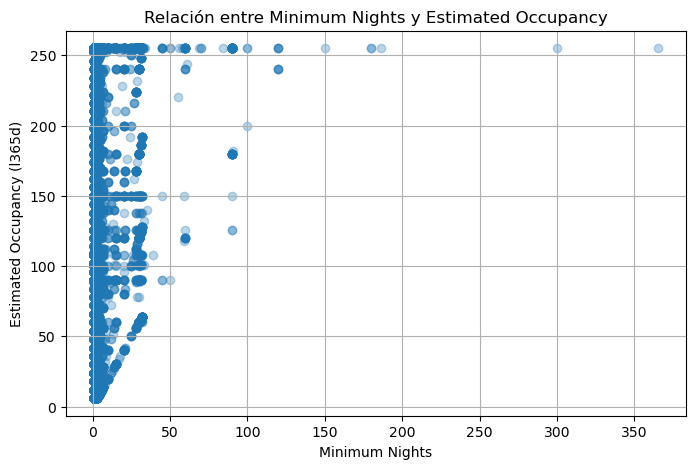

In [18]:
# yo: Gráfico de dispersión para visualizar la relación entre minimum_nights y estimated_occupancy_l365d
plt.figure(figsize=(8,5))
plt.scatter(df['minimum_nights'], df['estimated_occupancy_l365d'], alpha=0.3)
plt.xlabel('Minimum Nights')
plt.ylabel('Estimated Occupancy (l365d)')
plt.title('Relación entre Minimum Nights y Estimated Occupancy')
plt.grid(True)
plt.show()

In [28]:
df[(df['bedrooms'] > 3) & (df['bathrooms'] < 3)].shape[0]

120

In [34]:
#calcular m2 de cada inmueble para calculos posteriores
condiciones_m2 = [
    (df['bedrooms'] <=1),
    (df['bedrooms'] == 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] < 2),
    (df['bedrooms'] == 3) & (df['bathrooms'] >= 2),
    (df['bedrooms'] > 3) | (df['bathrooms'] >= 3),
]
opciones_m2 = [50, 65, 90, 110, 140]

df['m2_estimado'] = np.select(condiciones_m2, opciones_m2, default=np.nan)


In [35]:
df.m2_estimado.value_counts()

m2_estimado
50.0     10702
65.0      3181
110.0      715
90.0       258
140.0      190
Name: count, dtype: int64

In [36]:
#calcular coste inmueble
df['coste_inmueble'] = df['m2_estimado'] * df['precio_m2'] * 0.75

In [42]:
df.groupby('neighbourhood_group')['coste_inmueble'].mean().reset_index().sort_values(by='coste_inmueble', ascending=False)

,neighbourhood_group,coste_inmueble
14,Salamanca,479906.736551
5,Chamberí,387449.411765
4,Chamartín,359433.928942
13,Retiro,349646.761993
3,Centro,329522.925743
10,Moncloa - Aravaca,273703.083333
0,Arganzuela,272700.904059
16,Tetuán,260772.663934
8,Hortaleza,240992.412500
7,Fuencarral - El Pardo,237401.250000


In [47]:
df = df.rename(columns={'coste_inmueble':'coste_adquisicion'})

In [ ]:
#creacion de la variable de atractivo turistico
import sys
sys.path.insert(0, '../funciones')
from funciones import atractivo_turistico_0_100

poi_df = pd.read_csv('../datos/brutos/poi_madrid.csv')

df['atractivo_turistico'] = df.apply(lambda row: atractivo_turistico_0_100(row['latitude'], row['longitude'], poi_df), axis=1)

In [51]:
df.head()

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,...,bedrooms,beds,estimated_occupancy_l365d,review_scores_location,precio_m2,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion,atractivo_turistico
0,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Centro,Justicia,40.41884,-3.69655,Private room,64.0,1,314,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,...,1.0,2.0,204.0,4.97,7566.0,32.0,6528.0,50.0,283725.0,14.987660
1,Tu hogar en centro de Madrid.,Centro,Universidad,40.42381,-3.71038,Entire home/apt,86.0,7,5,"Very nice, cozy and bright, right in the cente...",...,1.0,1.0,28.0,4.95,7566.0,86.0,2408.0,50.0,283725.0,9.036372
2,Sunny attic duplex flat with terrace next to Sol,Centro,Embajadores,40.41150,-3.70449,Entire home/apt,196.0,3,169,"Nestled in the serene heart of Madrid, this re...",...,3.0,5.0,108.0,4.84,7566.0,196.0,21168.0,90.0,510705.0,9.603375
3,Cozy attic with intimate rooftop terrace+ elev...,Centro,Embajadores,40.40939,-3.69812,Entire home/apt,209.0,3,169,"Nestled in Madrid's tranquil heart, this apart...",...,3.0,3.0,162.0,4.92,7566.0,209.0,33858.0,90.0,510705.0,8.618188
4,*** MALASAÑA B&B ***,Centro,Universidad,40.42378,-3.70248,Private room,45.0,1,177,In Malasana. Excellent location.Central 150m a...,...,1.0,2.0,255.0,4.85,7566.0,22.5,5737.5,50.0,283725.0,9.405480


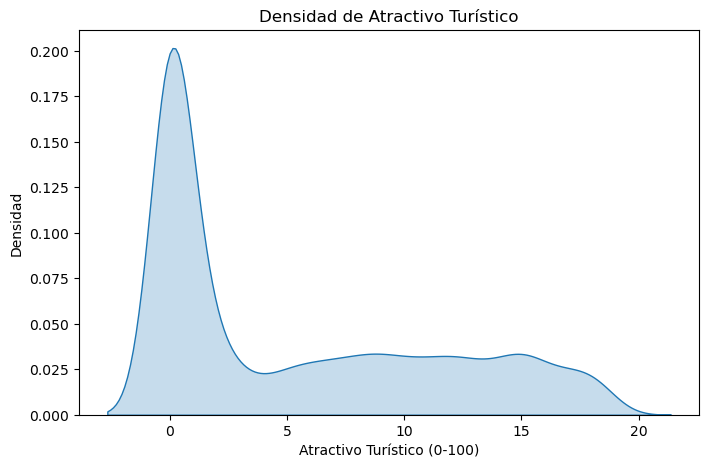

In [54]:
#grafico de densidad para la variable atractivo_turistico
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df['atractivo_turistico'], fill=True)
plt.title('Densidad de Atractivo Turístico')
plt.xlabel('Atractivo Turístico (0-100)')
plt.ylabel('Densidad')
plt.show()

In [ ]:
#La funcion esta ponderando de forma extraña y extablece que el mayor atractivo turistico es 20. Esto no afecta del todo al analisis
# ya que podemos adaptar la escala de 100 a 20 y usarla sin problemas. Ademas observamos que parece que hay 2 grafico superpuestos,
# uno de 0 a 4 y el otro de 4 a 20. Esto es debido a que posiblemente, haya un grupo de pisos mas enfocados al atractivo turistico y
# muchos otros que no lo estan y que su enfoque es mas el alquiler por temporadas largas.  

In [56]:
from funciones import mapa_atractivo_turistico

mapa_atractivo_turistico(df)

'mapa_atractivo_turistico.html'

In [58]:
# Cargar df a la base de datos
with sqlite3.connect(db_path) as conn:
    df.to_sql("df", conn, if_exists="replace", index=False)
    
print(f"DataFrame cargado a la tabla 'df' en {db_path}")

DataFrame cargado a la tabla 'df' en ../datos/intermedios/mercado_inmobiliario.db
